In [180]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import imageio

from torch.utils.data import DataLoader, TensorDataset

In [181]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import NN_LyapExp
from src.networks import SimpleFNN, SimpleFNN_Truncated, train_loop

In [182]:
hidden_dimension = 3

In [183]:
def circle_dataset(N_samples):
    assert N_samples % 2 == 0, "N_samples should be even for a balanced dataset"
    n_half = N_samples // 2

    # Sample inside the circle
    X_inside = []
    while len(X_inside) < n_half:
        x = np.random.uniform(-1, 1, size=(n_half * 2, 2))  # oversample a bit
        mask = np.sum(x**2, axis=1) <= 1
        X_inside.extend(x[mask])
    X_inside = np.array(X_inside[:n_half])

    # Sample outside the circle
    X_outside = []
    while len(X_outside) < n_half:
        x = np.random.uniform(-2, 2, size=(n_half * 2, 2))
        mask = np.sum(x**2, axis=1) > 1
        X_outside.extend(x[mask])
    X_outside = np.array(X_outside[:n_half])

    # Combine
    X = np.vstack([X_inside, X_outside])
    y_signed = np.array([-1]*n_half + [1]*n_half)

    return X, y_signed

In [184]:
N_samples = 36000

X_train, y_train = circle_dataset(N_samples)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_standardized = (X_train - mean)/std

In [185]:
N_samples_test = 4000
X_test, y_test = circle_dataset(N_samples_test)

X_test_standardized = (X_test - mean)/std

In [186]:
X_train_standardized = torch.tensor(X_train_standardized, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # add dimension if needed

X_test_standardized = torch.tensor(X_test_standardized, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [187]:
circle_fnn = SimpleFNN(hidden_dimension)


train_ds = TensorDataset(X_train_standardized, y_train)
test_ds = TensorDataset(X_test_standardized, y_test)

train_dataloader = DataLoader(train_ds, batch_size=4096, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=4096)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(circle_fnn.parameters(), lr=0.05)

In [188]:
x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)

lyap_grid_pt = np.zeros((len(x_vals), len(y_vals)))
circle_fnn_trunc_pt = SimpleFNN_Truncated(circle_fnn)

In [189]:
nn_lyap_pt = NN_LyapExp(circle_fnn_trunc_pt)  # your trained NN

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        x0 = torch.tensor([x, y], dtype=torch.float32).unsqueeze(0)
        x0 = (x0 - torch.tensor(mean, dtype=torch.float32)) / torch.tensor(std, dtype=torch.float32)
        # compute largest Lyapunov exponent
        J = nn_lyap_pt.jacobian(x0)
        svals = torch.linalg.svdvals(J)
        lyap_grid_pt[j, i] = torch.log(svals.max()).item() 

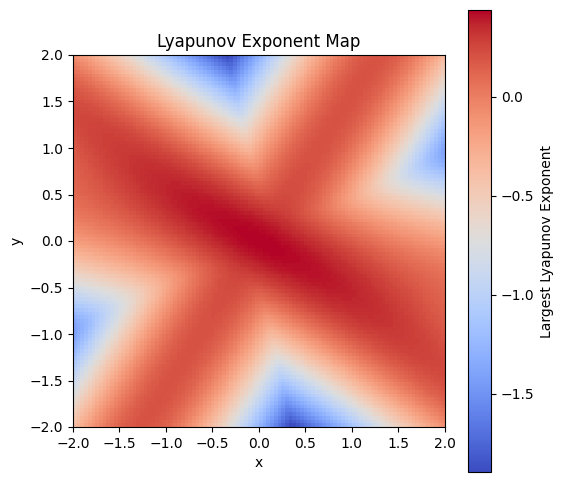

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(lyap_grid_pt, extent=[-2,2,-2,2], origin='lower', cmap='coolwarm')
plt.colorbar(label='Largest Lyapunov Exponent')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lyapunov Exponent Map')
plt.show()

In [191]:
os.makedirs('lyap_frames', exist_ok=True)

In [192]:
batch_size = len(train_dataloader.dataset)
num_epochs = 200
frame_files = []

circle_fnn.train()
image = False

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch, (X,y) in enumerate(train_dataloader):
        # X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = circle_fnn(X)
        loss = loss_fn(pred, y)


        loss.backward()
        optimizer.step()
        

        total_loss += loss.item()

        if batch % 100 == 0:
            current = batch * len(X)
            print(f"Epoch {epoch+1:03d} | Batch {batch:03d} | Loss: {loss.item():.6f}")
    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch+1:03d} complete — Average loss: {avg_loss:.6f}\n")

    if image:
        lyap_grid = torch.zeros(len(y_vals), len(x_vals))
        circle_fnn_tr2 = SimpleFNN_Truncated(circle_fnn)
        nn_lyap_tr = NN_LyapExp(circle_fnn_tr2)

        for i, x in enumerate(x_vals):
            for j, y in enumerate(y_vals):
                x0 = torch.tensor([x, y], dtype=torch.float32).unsqueeze(0)
                x0 = (x0 - torch.tensor(mean, dtype=torch.float32)) / torch.tensor(std, dtype=torch.float32)
                # compute largest Lyapunov exponent
                J = nn_lyap_tr.jacobian(x0)
                svals = torch.linalg.svdvals(J)
                lyap_grid[j, i] = torch.log(svals.max()).item()  # pick largest LE

        plt.figure(figsize=(6,6))
        plt.imshow(lyap_grid, extent=[-2,2,-2,2], origin='lower', cmap='coolwarm', vmin=-2, vmax=2)
        plt.title(f'Lyapunov Exponents, Epoch {epoch+1}')
        plt.colorbar(label='Max LE')
        plt.xlabel('x'); plt.ylabel('y')
        
        frame_filename = f'lyap_frames/lyap_epoch_{epoch+1:04d}.png'
        plt.savefig(frame_filename)
        plt.close()
        frame_files.append(frame_filename)

    
print("Training finished!")
            

Epoch 001 | Batch 000 | Loss: 1.077508
Epoch 001 complete — Average loss: 1.039240

Epoch 002 | Batch 000 | Loss: 1.012203
Epoch 002 complete — Average loss: 1.010143

Epoch 003 | Batch 000 | Loss: 1.002362
Epoch 003 complete — Average loss: 1.000998

Epoch 004 | Batch 000 | Loss: 0.998390
Epoch 004 complete — Average loss: 0.997330

Epoch 005 | Batch 000 | Loss: 0.996954
Epoch 005 complete — Average loss: 0.994948

Epoch 006 | Batch 000 | Loss: 0.995169
Epoch 006 complete — Average loss: 0.992542

Epoch 007 | Batch 000 | Loss: 0.991471
Epoch 007 complete — Average loss: 0.989493

Epoch 008 | Batch 000 | Loss: 0.987313
Epoch 008 complete — Average loss: 0.985449

Epoch 009 | Batch 000 | Loss: 0.981842
Epoch 009 complete — Average loss: 0.980088

Epoch 010 | Batch 000 | Loss: 0.975437
Epoch 010 complete — Average loss: 0.972970

Epoch 011 | Batch 000 | Loss: 0.969620
Epoch 011 complete — Average loss: 0.963869

Epoch 012 | Batch 000 | Loss: 0.959196
Epoch 012 complete — Average loss: 0.

In [193]:
with imageio.get_writer('lyapunov_evolution.gif', mode='I', duration=0.3) as writer:
    for filename in frame_files:
        image = imageio.imread(filename)
        writer.append_data(image)

In [194]:
def accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            predicted = (pred > 0).float() * 2 - 1  # map to [-1, 1]
            correct += (predicted == y).sum().item()

            total += y.size(0)
    return correct / total

train_acc = accuracy(circle_fnn, train_dataloader)
test_acc = accuracy(circle_fnn, test_dataloader)
print(f"Train Accuracy: {train_acc*100:.2f}% | Test Accuracy: {test_acc*100:.2f}%")

Train Accuracy: 97.55% | Test Accuracy: 97.67%


In [195]:
lyap_grid = np.zeros((len(x_vals), len(y_vals)))

circle_fnn_trunc = SimpleFNN_Truncated(circle_fnn)

In [196]:
X, Y = np.meshgrid(x_vals, y_vals)

points = np.stack([X.ravel(), Y.ravel()], axis=1)

points_t = torch.tensor(points, dtype=torch.float32)

In [197]:
with torch.no_grad():
    preds = circle_fnn_trunc(points_t)
    preds_full = circle_fnn(points_t).cpu().numpy().reshape(len(y_vals), len(x_vals))

Z = preds

In [198]:
import pandas as pd

data = pd.DataFrame({
    'x': points_t[:,0].numpy(),
    'y': points_t[:,1].numpy(),
    'h1': Z[:,0].numpy(),
    'h2': Z[:,1].numpy(),
    'h3': Z[:,2].numpy()  # only if hidden_dim>=3
})

In [199]:
# x_norm = (points_t[:, 0] - points_t[:, 0].min()) / (points_t[:, 0].max() - points_t[:, 0].min())
# y_norm = (points_t[:, 1] - points_t[:, 1].min()) / (points_t[:, 1].max() - points_t[:, 1].min())

# colors = np.stack([x_norm, y_norm, np.zeros_like(x_norm)], axis=1)  # RGB: x->R, y->G, B=0
r = torch.sqrt(points_t[:,0]**2 + points_t[:,1]**2)
inside_mask = (r <= 1.0)        # True = inside, False = outside

colors = np.zeros((len(points_t), 3))  # outside = blue
colors[inside_mask.numpy()] = [1, 0, 0]  # inside = red

In [200]:
nn_lyap = NN_LyapExp(circle_fnn_trunc)  # your trained NN

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        x0 = torch.tensor([x, y], dtype=torch.float32).unsqueeze(0)
        x0 = (x0 - torch.tensor(mean, dtype=torch.float32)) / torch.tensor(std, dtype=torch.float32)
        # compute largest Lyapunov exponent
        J = nn_lyap.jacobian(x0)
        svals = torch.linalg.svdvals(J)
        lyap_grid[j, i] = torch.log(svals.min()).item()  # pick largest LE

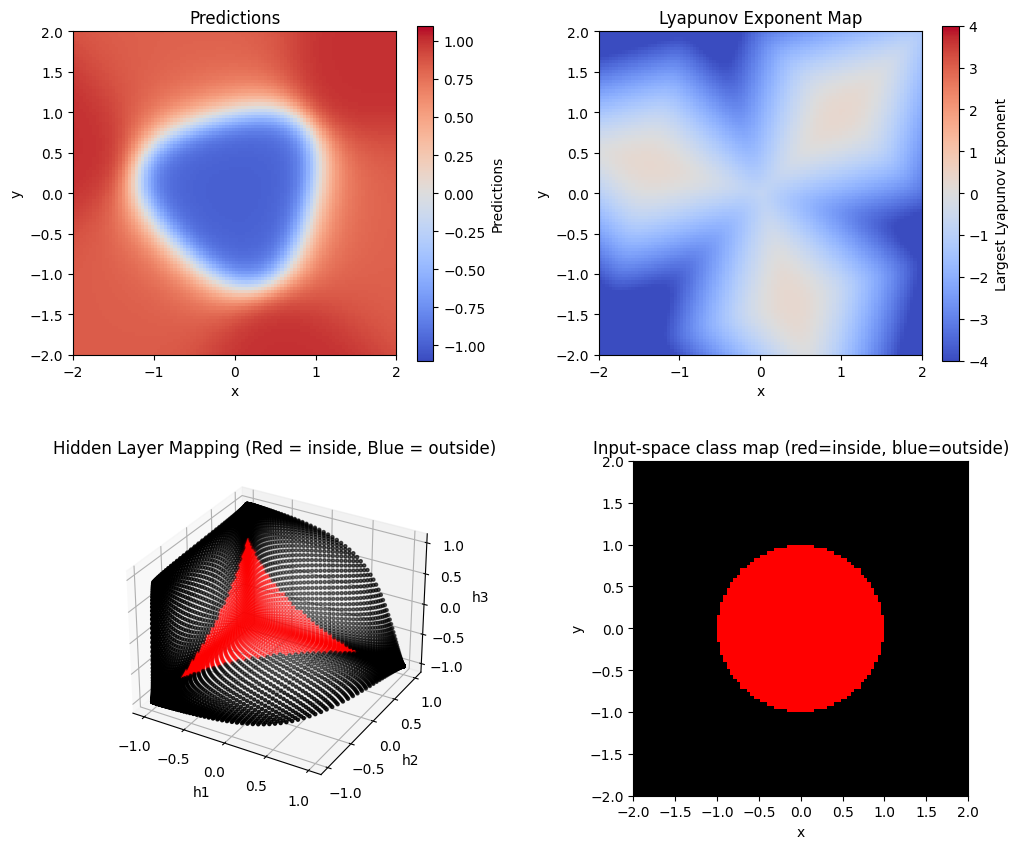

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1,1],
                       hspace=0.3, wspace=0.3)

# ----- Top left: true values predictions
ax0 = fig.add_subplot(gs[0, 0])
im2 = ax0.imshow(preds_full, extent=[-2, 2, -2, 2], origin='lower',
                cmap='coolwarm', vmin=-1.1, vmax=1.1)
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.set_title('Predictions')
fig.colorbar(im2, ax=ax0, label='Predictions')

# ----- Top right: Lyapunov exponents (spanning both columns) -----
ax1 = fig.add_subplot(gs[0, 1])
im = ax1.imshow(lyap_grid, extent=[-2, 2, -2, 2], origin='lower',
                cmap='coolwarm', vmin=-4, vmax=4)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Lyapunov Exponent Map')
fig.colorbar(im, ax=ax1, label='Largest Lyapunov Exponent')

# ----- Bottom left: 3D hidden-layer scatter -----
ax2 = fig.add_subplot(gs[1, 0], projection='3d')
ax2.scatter(Z[:,0], Z[:,1], Z[:,2], color=colors, s=5)
ax2.set_xlabel('h1'); ax2.set_ylabel('h2'); ax2.set_zlabel('h3')
ax2.set_title('Hidden Layer Mapping (Red = inside, Blue = outside)')

# ----- Bottom right: Class legend (2-color grid) -----
ax3 = fig.add_subplot(gs[1, 1])
color_grid = colors.reshape(len(y_vals), len(x_vals), 3)
ax3.imshow(color_grid, origin='lower',
           extent=[x_vals.min(), x_vals.max(),
                   y_vals.min(), y_vals.max()])
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Input-space class map (red=inside, blue=outside)')

plt.show()

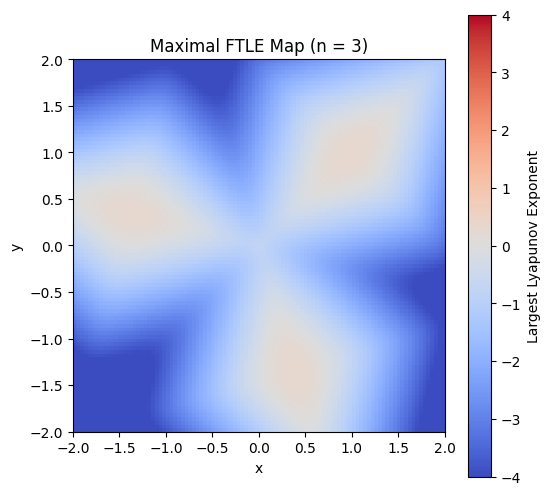

In [202]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    lyap_grid,
    extent=[-2, 2, -2, 2],
    origin='lower',
    cmap='coolwarm',
    vmin=-4,
    vmax=4
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Maximal FTLE Map (n = 3)')

fig.colorbar(im, ax=ax, label='Largest Lyapunov Exponent')

plt.show()